# Tesis - MDM UBA - 2026

**Tariff classification using NLP**

By Santiago Tedoldi

# Scoring output

In [1]:
import os
import json
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizerFast

from hs04_distilbert_inference import HSClassifier


class HSDataset(Dataset):
    def __init__(self, dataframe, tokenizer, desc_col='', label_col='', max_length=500):
        self.descriptions = dataframe[desc_col].tolist()
        self.labels = dataframe[label_col].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.descriptions)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.descriptions[idx],
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_token_type_ids=False,
            return_attention_mask=True,
            return_tensors='pt'
        )
        item = {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': self.labels[idx],
            'description': self.descriptions[idx]
        }
        return item


# Function to extract [CLS] embeddings
def get_embeddings(dataloader, model, device):
    all_embeds = []
    all_labels = []
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attn = batch['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attn)
            # DistilBERT does not have pooler; use first token hidden state
            cls_embeds = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            all_embeds.append(cls_embeds)
            all_labels.extend(batch['label'])
    return np.vstack(all_embeds), np.array(all_labels)


dtypes = {
    'Description': str,
    'True Label': str,
    'Top1': str,
    'Top2': str,
    'Top3': str,
    'Top4': str,
    'Top5': str,
}

results_finetuned = pd.read_csv(
    'results/distilbert/fft_final/final_val_predictions.csv',
    index_col=0,
    dtype=dtypes,
)

In [2]:
torch.cuda.empty_cache()

Loading models

In [3]:
# loading final model artifacts
with open('results/distilbert/fft_final/final_model/training_config.json', 'r') as f:
    model_config = json.load(f)

with open('results/distilbert/fft_final/labels/labels_dict_FINAL_DBERT_fft_GOODS_DESCRIPTION_HS04_seed32.json', 'r') as f:
    labels_dict = json.load(f)

label2id = labels_dict['label2id']
id2label = {int(k): v for k, v in labels_dict['id2label'].items()}

# loading tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

# loading final model
model_path = 'results/distilbert/fft_final/final_model/pytorch_model.bin'
model_final = HSClassifier(
    n_classes=len(label2id),
    fine_tune=model_config.get('fine_tune', False),
    n_finetune_layers=model_config.get('n_finetune_layers', 0),
)

state_dict = torch.load(model_path, map_location='cpu')
model_final.load_state_dict(state_dict)

# Keep legacy variable names to avoid downstream code changes
model_finetuned2 = model_final
model_finetuned = model_final

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
model_final.to(device)
model_final.eval()  # to set the model for inference


C:\Users\santt\AppData\Local\Temp\ipykernel_31316\1994254139.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(model_path, map_location='cpu')


Using device: cuda


HSClassifier(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (lin1): Lin

Getting test embeddings

In [4]:
# results_finetuned
ds = HSDataset(
    results_finetuned,
    tokenizer,
    desc_col='Description',
    label_col='True Label',
    max_length=model_config['max_length'],
)

loader = DataLoader(ds, batch_size=128, shuffle=False)

embeds_finetuned, labels_finetuned = get_embeddings(loader, model_final.distilbert, device)
print('Embeddings shape:', embeds_finetuned.shape)


Embeddings shape: (2677, 768)


Merging with HS06 nomenclature

In [5]:
df_hs06 = pd.read_csv(
    'data/hs06_full_eng.csv',
    dtype={'hs06': str, 'full_eng': str},
    usecols=['hs06', 'full_eng'],
)

# Build a single legal-text row per HS04 (first available HS06 description per HS04)
df_hs04_text = (
    df_hs06.assign(hs04=df_hs06['hs06'].astype(str).str[:4])
    .dropna(subset=['full_eng'])
    .drop_duplicates(subset=['hs04'], keep='first')
    .loc[:, ['hs04', 'full_eng']]
    .rename(columns={'hs04': 'True Label'})
)

# Embed HS04 legal text so we can compute desc-vs-legal cosine similarity
ds_full_eng = HSDataset(
    df_hs04_text.rename(columns={'full_eng': 'Description'}),
    tokenizer,
    desc_col='Description',
    label_col='True Label',
    max_length=model_config['max_length'],
)
loader_full_eng = DataLoader(ds_full_eng, batch_size=128, shuffle=False)
embeds_full_eng, labels_full_eng = get_embeddings(loader_full_eng, model_final.distilbert, device)
print('HS04 legal-text embeddings shape:', embeds_full_eng.shape)

# Merge legal text into scored predictions
df_hs04_text = df_hs04_text.set_index('True Label')
results_finetuned = pd.merge(results_finetuned, df_hs04_text, how='left', left_on='True Label', right_index=True)


HS04 legal-text embeddings shape: (942, 768)


Cosine similarity between description and full eng nomenclature

In [6]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Map HS04 code ? corresponding legal text embedding
hs04_to_hsvec = {}
for hs_code, emb in zip(labels_full_eng, embeds_full_eng):
    hs04_to_hsvec[str(hs_code)] = emb


In [7]:
# results_finetuned
cosine_sims = []

for i in range(len(embeds_finetuned)):
    hs_code = str(labels_finetuned[i])  # ensure string matching
    gd_vec = embeds_finetuned[i].reshape(1, -1)  # shape (1, dim)

    hs_vec = hs04_to_hsvec.get(hs_code)

    if hs_vec is not None:
        hs_vec = hs_vec.reshape(1, -1)
        sim = cosine_similarity(gd_vec, hs_vec)[0][0]
    else:
        sim = np.nan  # if no match found, assign NaN

    cosine_sims.append(sim)

results_finetuned['cosine_sim_desc_vs_hs_text'] = cosine_sims


In [8]:
results_finetuned.head()

,Description,True Label,Top1,Proba Top1,Top2,Proba Top2,Top3,Proba Top3,Top4,Proba Top4,Top5,Proba Top5,full_eng,cosine_sim_desc_vs_hs_text
354196,sterilizing cabinet,8419,9402,0.265925,9403,0.247374,9018,0.227738,8419,0.099247,8537,0.027063,"Machinery, plant or laboratory equipment, whet...",0.404270
155635,PERFUMES-LOVE INTETION,3303,3303,0.942016,3307,0.036050,3302,0.015176,3301,0.001438,3304,0.000576,NaN,NaN
134060,High voltage insulating tape,3920,8546,0.445084,3919,0.234640,5906,0.089700,3920,0.048213,3921,0.029814,"Other plates, sheets, film, foil and strip, of...",0.485572
114018,BEARING 6805 ZZ BRAND KG,8482,8482,0.995477,8483,0.000293,7319,0.000043,8711,0.000042,7009,0.000021,Ball or roller bearings. && - Ball bearings,0.829166
264869,USED SOFA 3SEATER,9403,9403,0.621796,9401,0.366761,9404,0.001297,8715,0.000630,9402,0.000514,Other furniture and parts thereof. && - Metal ...,0.636881


More feature engineering

In [9]:
def create_proba_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Given a DataFrame with columns
      ['Description', 'True Label',
       'Top1', 'Proba Top1', 'Top2', 'Proba Top2', …, 'Top5', 'Proba Top5',
       'cosine_sim_desc_vs_hs_text'],
    this function:
      1) Ignores the 'TopN' category columns
      2) Finds the five probability columns
      3) Computes:
         - prob_mean
         - prob_max
         - prob_min
         - prob_range (max - min)
         - prob_std
         - all pairwise differences prob_i - prob_j for i<j
      4) Leaves cosine_sim_desc_vs_hs_text in place
      5) Returns a new DataFrame with these additional feature columns.
    """
    # Identify the probability columns automatically
    prob_cols = [c for c in df.columns if c.startswith("Proba Top")]
    if len(prob_cols) != 5:
        raise ValueError(f"Expected 5 Proba TopN columns, found: {prob_cols!r}")
    
    probs = df[prob_cols]
    
    # summary statistics
    df = df.copy()
    df['prob_mean']  = probs.mean(axis=1)
    df['prob_max']   = probs.max(axis=1)
    df['prob_min']   = probs.min(axis=1)
    df['prob_range'] = df['prob_max'] - df['prob_min']
    df['prob_std']   = probs.std(axis=1)
    
    # pairwise differences: Proba Top1 - Proba Top2, Proba Top1 - Proba Top3, ..., Proba Top4 - Proba Top5
    for i, j in itertools.combinations(range(1, 6), 2):
        ci = f"Proba Top{i}"
        cj = f"Proba Top{j}"
        df[f'prob_diff_{i}_{j}'] = df[ci] - df[cj]
    
    # (cosine_sim_desc_vs_hs_text is already in df; if you want to rename:)
    # df = df.rename(columns={
    #                         'Proba Top1': 'prob_top1',
    #                         'Proba Top2': 'prob_top2',
    #                         'Proba Top3': 'prob_top3',
    #                         'Proba Top4': 'prob_top4',
    #                         'Proba Top5': 'prob_top5',
    #                         'True Label': 'true_label',
    #                         'cosine_sim_desc_vs_hs_text': 'cosine_sim'
    #                         })
    
    return df

In [10]:
results_finetuned = create_proba_features(results_finetuned)

Classification score

In [11]:
def assign_score_and_topn_flags(
    df: pd.DataFrame,
    true_label_col: str = "True Label",
    top_prefix: str = "Top",
    max_rank: int = 5,
    score_col: str = "score"
) -> pd.DataFrame:
    """
    Adds:
      - a 'score' column with:
          Score = 10       if True Label == Top1
          Score = 10 - 1   if True Label == Top2
          Score = 10 - 2   if True Label == Top3
          ...
          Score = 10 - (rank-1)  for Top{rank}
          Score = 0        if True Label not in Top1..Top{max_rank}
      - cumulative top-k flags:
          top1_true = 1 if True Label == Top1, else 0
          top2_true = 1 if True Label in [Top1,Top2], else 0
          …
          top{max_rank}_true = 1 if True Label in Top1..Top{max_rank}, else 0

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing at least the columns:
          [true_label_col, Top1, Top2, …, Top{max_rank}]
    true_label_col : str
        Name of the column with the ground-truth label.
    top_prefix : str
        Prefix for the predicted rank columns (e.g. "Top" for "Top1", …).
    max_rank : int
        How many TopN columns there are.
    score_col : str
        Name of the output score column.

    Returns
    -------
    pd.DataFrame
        A copy of the input DataFrame with new columns:
        [score, top1_true, …, top{max_rank}_true].
    """
    df = df.copy()

    def _get_score(row):
        # If found at rank r, return 10 - (r-1) == 11 - r
        for r in range(1, max_rank + 1):
            if row[true_label_col] == row[f"{top_prefix}{r}"]:
                return 11 - r
        return 0

    # Compute score directly (no NaNs)
    df[score_col] = df.apply(_get_score, axis=1).astype(int)

    # Compute cumulative top-k flags
    for k in range(1, max_rank + 1):
        cols = [f"{top_prefix}{i}" for i in range(1, k + 1)]
        df[f"top{k}_true"] = (
            df[cols]
            .eq(df[true_label_col], axis=0)
            .any(axis=1)
            .astype(int)
        )

    return df

In [12]:
results_finetuned = assign_score_and_topn_flags(results_finetuned)


### Confidence meta-model

In [13]:
def plot_predicted_violin(y_true, y_pred, title="Predicted Score Distribution by True Score"):
    """
    Plots violin distributions of predicted scores grouped by the discrete true score values.
    
    Parameters
    ----------
    y_true : array-like of shape (n_samples,)
        Discrete true score values (e.g., integers 0–10).
    y_pred : array-like of shape (n_samples,)
        Continuous predicted score values from your regression model.
    title : str
        Title of the plot.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    unique_scores = np.unique(y_true)
    data = [y_pred[y_true == score] for score in unique_scores]

    plt.figure(figsize=(8, 6))
    plt.violinplot(data, positions=unique_scores, showmeans=True)
    plt.xlabel("True Score")
    plt.ylabel("Predicted Score")
    plt.title(title)
    plt.xticks(unique_scores)
    plt.tight_layout()
    plt.show()

    residuals = y_true - y_pred
    plt.figure(figsize=(8,6))
    plt.hist(residuals, bins=20, edgecolor='black')
    plt.axvline(0, color='k', linestyle='--')
    plt.xlabel("Residual (True – Pred)")
    plt.ylabel("Count")
    plt.title(title + " - Residuals")
    plt.tight_layout()
    plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

FEATURE_COLS = [
    'Proba Top1','Proba Top2','Proba Top3','Proba Top4','Proba Top5',
    'cosine_sim_desc_vs_hs_text','prob_mean','prob_max','prob_min','prob_range',
    'prob_std','prob_diff_1_2','prob_diff_1_3','prob_diff_1_4','prob_diff_1_5',
    'prob_diff_2_3','prob_diff_2_4','prob_diff_2_5','prob_diff_3_4','prob_diff_3_5',
    'prob_diff_4_5'
]

# Prepare data
X = results_finetuned[FEATURE_COLS].fillna(0)  # fill NaNs with 0
y = results_finetuned['score'].astype(float)  # ensure numeric

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# HistGradientBoostingRegressor
hgb = HistGradientBoostingRegressor(random_state=42)
hgb.fit(X_train, y_train)
y_pred_hgb = hgb.predict(X_test)

print("HistGradientBoostingRegressor")
print("  MAE: ", mean_absolute_error(y_test, y_pred_hgb))
print("  RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_hgb)))

# RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\nRandomForestRegressor")
print("  MAE: ", mean_absolute_error(y_test, y_pred_rf))
print("  RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

HistGradientBoostingRegressor
  MAE:  1.3195131461027898
  RMSE: 2.3556476691085186

RandomForestRegressor
  MAE:  1.3263248720359806
  RMSE: 2.281429088726974


In [15]:
df_eval = X_test.copy()
df_eval['score_true']     = y_test
df_eval['score_pred_hgb'] = y_pred_hgb
df_eval['score_pred_rf']  = y_pred_rf

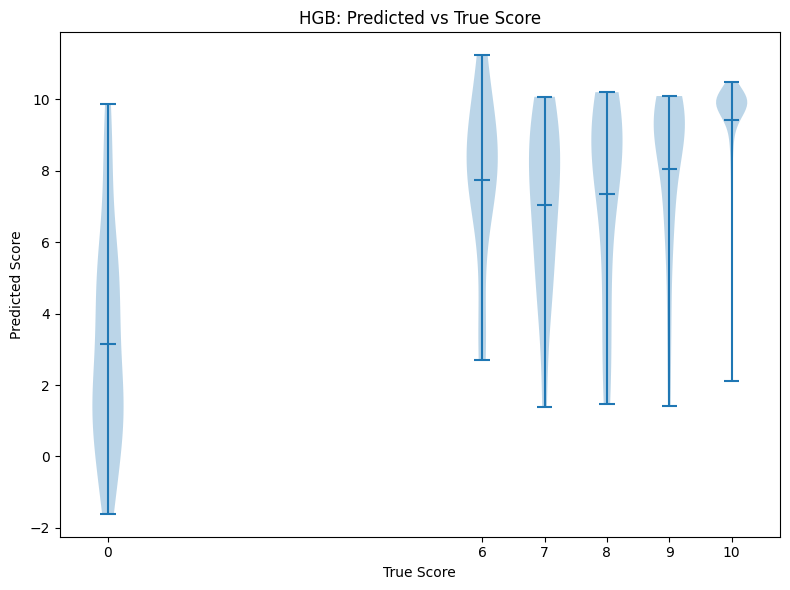

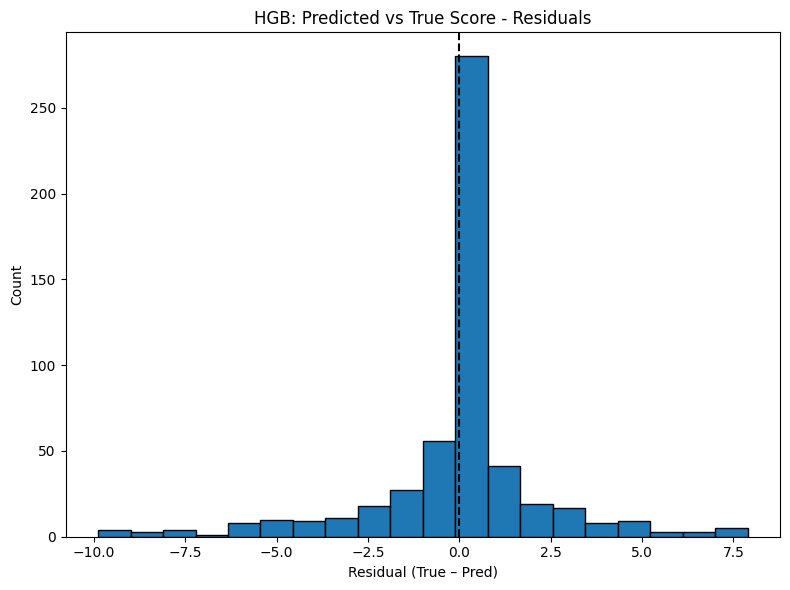

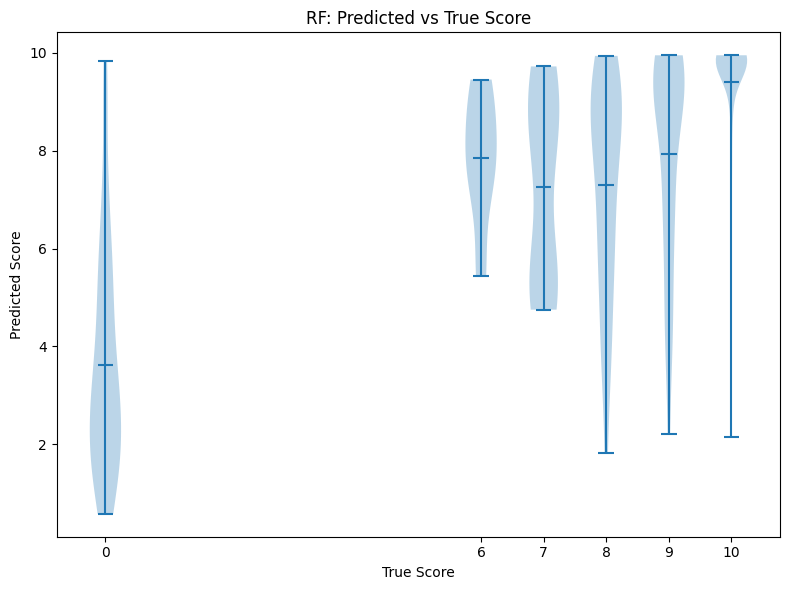

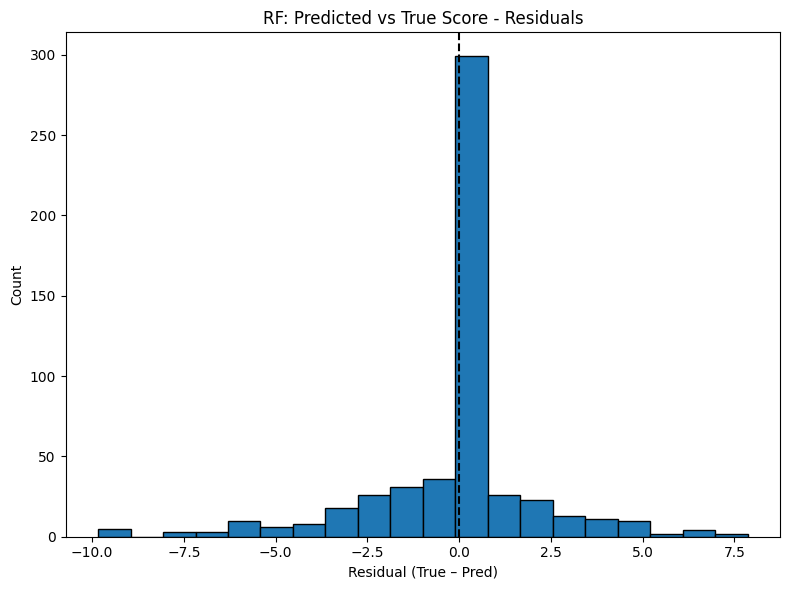

In [16]:
plot_predicted_violin(y_test, y_pred_hgb, title="HGB: Predicted vs True Score")
plot_predicted_violin(y_test, y_pred_rf,  title="RF: Predicted vs True Score")

Testing Full Fine-tune performance with score threshold

In [17]:
df_eval

,Proba Top1,Proba Top2,Proba Top3,Proba Top4,Proba Top5,cosine_sim_desc_vs_hs_text,prob_mean,prob_max,prob_min,prob_range,...,prob_diff_1_5,prob_diff_2_3,prob_diff_2_4,prob_diff_2_5,prob_diff_3_4,prob_diff_3_5,prob_diff_4_5,score_true,score_pred_hgb,score_pred_rf
252252,0.983532,0.003717,0.001297,0.001179,0.000993,0.890788,0.198144,0.983532,0.000993,0.982539,...,0.982539,0.002421,0.002539,0.002724,0.000118,0.000304,0.000186,10.0,9.919255,9.945978
5895,0.973713,0.020584,0.000193,0.000106,0.000095,0.852721,0.198938,0.973713,0.000095,0.973618,...,0.973618,0.020391,0.020478,0.020489,0.000087,0.000097,0.000011,10.0,9.901334,9.934549
197656,0.886576,0.095537,0.010084,0.004998,0.000743,0.000000,0.199588,0.886576,0.000743,0.885833,...,0.885833,0.085454,0.090539,0.094795,0.005085,0.009341,0.004255,7.0,9.412739,7.972270
215081,0.200810,0.035443,0.034646,0.029232,0.028046,0.221191,0.065635,0.200810,0.028046,0.172764,...,0.172764,0.000796,0.006211,0.007397,0.005415,0.006601,0.001186,0.0,0.353098,1.180862
236532,0.998821,0.000597,0.000119,0.000074,0.000055,0.000000,0.199933,0.998821,0.000055,0.998766,...,0.998766,0.000478,0.000523,0.000542,0.000046,0.000064,0.000018,10.0,10.097465,9.946335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169083,0.997350,0.000723,0.000664,0.000189,0.000110,0.754981,0.199807,0.997350,0.000110,0.997241,...,0.997241,0.000059,0.000534,0.000613,0.000475,0.000554,0.000079,10.0,10.017219,9.953012
497176,0.859445,0.117892,0.005862,0.003711,0.003240,0.600026,0.198030,0.859445,0.003240,0.856205,...,0.856205,0.112030,0.114181,0.114652,0.002152,0.002623,0.000471,10.0,9.471949,9.779051
443478,0.997002,0.000206,0.000183,0.000163,0.000159,0.710164,0.199543,0.997002,0.000159,0.996842,...,0.996842,0.000023,0.000043,0.000047,0.000020,0.000024,0.000004,10.0,9.969483,9.951383
140839,0.530752,0.134586,0.060126,0.051274,0.048576,0.437561,0.165063,0.530752,0.048576,0.482175,...,0.482175,0.074460,0.083312,0.086010,0.008852,0.011550,0.002698,7.0,1.373493,5.638281


Using score_pred_hgb to prevent wrong classifications

In [18]:
# accuracy without filters
100*len(df_eval.where(df_eval['score_true'] > 5).dropna())/len(df_eval)

83.0223880597015

In [19]:
# accuracy with score_pred_hgb > 4
df_eval_filtered = df_eval.where(df_eval['score_pred_hgb'] > 4).dropna()
100*len(df_eval_filtered.where(df_eval_filtered['score_true'] > 4).dropna())/len(df_eval_filtered)

92.84164859002169

In [20]:
# missing classifications %
100*(len(df_eval) - len(df_eval_filtered)) / len(df_eval)

13.992537313432836

In [21]:
# missing classifications
len(df_eval) - len(df_eval_filtered)

75

In [22]:
# rejected classifications
rejected_clas = df_eval.where(df_eval['score_pred_hgb'] <= 4).dropna().sort_values(by='score_true', ascending=False)

In [23]:
df_rejected_clas = results_finetuned.loc[rejected_clas.index]

In [24]:
df_rejected_clas.where(df_rejected_clas['score'] > 5).dropna().sort_values(by='score', ascending=False)

,Description,True Label,Top1,Proba Top1,Top2,Proba Top2,Top3,Proba Top3,Top4,Proba Top4,...,prob_diff_2_5,prob_diff_3_4,prob_diff_3_5,prob_diff_4_5,score,top1_true,top2_true,top3_true,top4_true,top5_true
449294,"WIRELINE PACKER HQ (56MM) TYPE B, RUBBER LENGT...",8431,8431,0.883787,7312,0.032314,8425,0.021106,8422,0.008725,...,0.026221,0.012382,0.015013,0.002631,10.0,1.0,1.0,1.0,1.0,1.0
417730,CHARGING TREASURE,8504,8504,0.200421,9504,0.129754,8207,0.057185,8431,0.046643,...,0.093113,0.010542,0.020545,0.010002,10.0,1.0,1.0,1.0,1.0,1.0
344299,SLEEVE PORTA SONDE A SALDARE G 1/4X6 A316,8422,8422,0.181071,8483,0.167176,7307,0.127767,8482,0.083475,...,0.106289,0.044291,0.066879,0.022588,10.0,1.0,1.0,1.0,1.0,1.0
70713,OIL INDICATOR AKC 1C300020-AS,9026,9026,0.350755,9031,0.074842,2710,0.064109,3811,0.060331,...,0.039363,0.003778,0.028630,0.024852,10.0,1.0,1.0,1.0,1.0,1.0
123882,VOE11704359 SEALANT,3214,3506,0.492867,3214,0.150820,3919,0.033151,3208,0.032125,...,0.126260,0.001026,0.008591,0.007565,9.0,0.0,1.0,1.0,1.0,1.0
9159,Fabric roll and swatch sample blanket,6006,6114,0.147391,6006,0.124692,5903,0.107113,5407,0.101967,...,0.081651,0.005147,0.064072,0.058925,9.0,0.0,1.0,1.0,1.0,1.0
105231,MICRONUTRIENT PREMIX BRAND:ALCOVIT 201140,2106,2309,0.729153,2106,0.062258,3808,0.049516,1302,0.021243,...,0.044968,0.028274,0.032226,0.003953,9.0,0.0,1.0,1.0,1.0,1.0
430166,"USED STEAM CLEANERS ,VACUUMS& FLOOR CARE ACCES...",8424,8508,0.916987,8424,0.017689,8509,0.009036,9617,0.004845,...,0.012912,0.004191,0.004259,0.000068,9.0,0.0,1.0,1.0,1.0,1.0
8161,13X MOLECULAR SIEVE,3824,9604,0.284078,9027,0.152658,3824,0.147919,9024,0.058430,...,0.107700,0.089489,0.102961,0.013472,8.0,0.0,0.0,1.0,1.0,1.0
111839,STEERING CYCLINDER REPAIR KIT,4016,8708,0.902430,8431,0.020390,4016,0.015852,8409,0.007850,...,0.013052,0.008001,0.008514,0.000512,8.0,0.0,0.0,1.0,1.0,1.0


## Conclusions
